In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px

In [2]:
dfUsersRatings = pd.read_csv("../data/cleaned/users_ratings.csv")

In [3]:
dfUsersRatings = dfUsersRatings.sample(500_000, random_state=42)

In [6]:
dfUsersRatings

,username,anime_id,status,score,num_watched_episodes
0,--------788,30276,watching,7,3
1,--------788,28851,completed,7,1
2,--------788,41168,completed,7,1
3,--------788,22199,completed,10,24
4,--------788,16498,completed,10,25
...,...,...,...,...,...
124294770,arizkim,52305,plan_to_watch,0,0
124294771,arizkim,4224,plan_to_watch,0,0
124294772,arizkim,54790,plan_to_watch,0,0
124294773,arizkim,53835,plan_to_watch,0,0


<Axes: xlabel='score', ylabel='Count'>

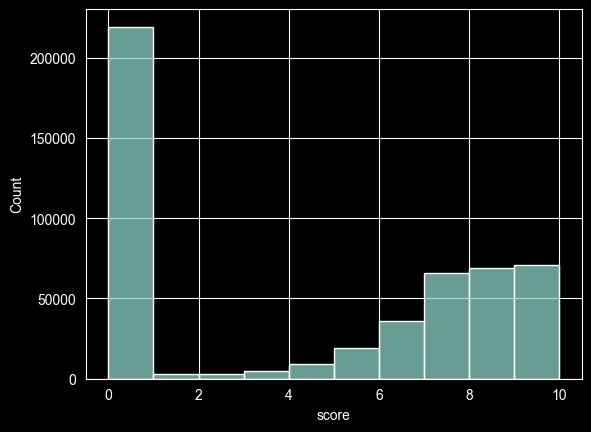

In [10]:
sns.histplot(dfUsersRatings["score"], bins=10)

<Axes: xlabel='status', ylabel='count'>

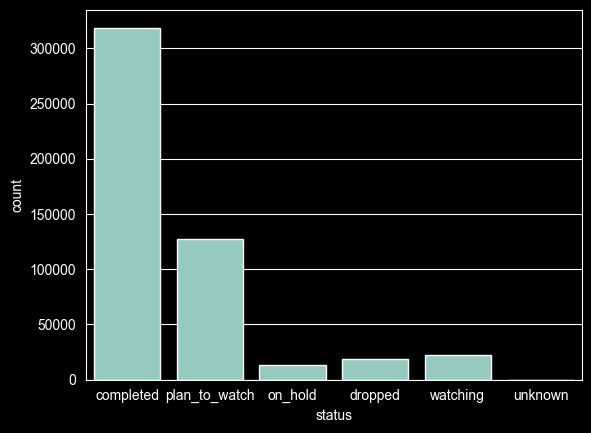

In [11]:
sns.countplot(data=dfUsersRatings, x="status")

In [16]:
px.scatter(dfUsersRatings, y="num_watched_episodes", x="score", opacity=0.3)

<Axes: xlabel='status', ylabel='score'>

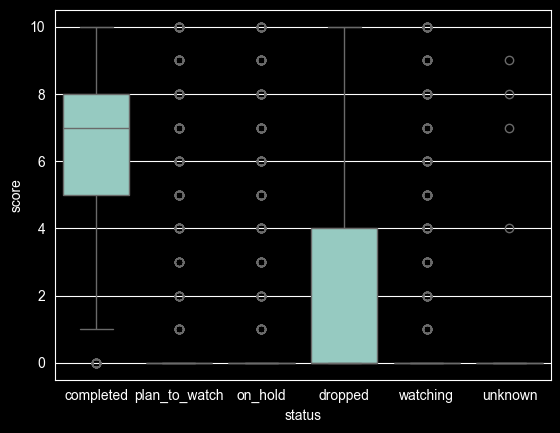

In [17]:
sns.boxplot(data=dfUsersRatings, x="status", y="score")


In [6]:
dfUsersRatings = None

In [30]:
dfUsersFavs = pd.read_csv("../data/cleaned/users_favs.csv")
dfUsersFavs

,Unnamed: 0,username,fav_type,id
0,0,ishikawas,anime,45649
1,1,ishikawas,anime,38680
2,2,ishikawas,anime,795
3,3,ishikawas,anime,37510
4,4,ishikawas,anime,820
...,...,...,...,...
4178738,4178742,vincent0607,character,497
4178739,4178743,vincent0607,character,118739
4178740,4178744,vincent0607,character,188177
4178741,4178745,vincent0607,character,141354


In [28]:
dfAnime = pd.read_csv("../data/cleaned/anime.csv", usecols=["mal_id", "title", "score"])

In [ ]:
fav_anime = dfUsersFavs[dfUsersFavs["fav_type"] == "anime"]
fav_anime = fav_anime.drop(columns=["fav_type"])
dfUsersFavs = None

In [31]:
dfAnime = dfAnime.merge(fav_anime, left_on="mal_id", right_on="id")
dfAnime

,mal_id,title,score,Unnamed: 0,username,fav_type,id
0,56036,......,6.53,3295237,SwowoJonny,anime,56036
1,2928,.hack//G.U. Returner,6.65,2394355,Ikano,anime,2928
2,3269,.hack//G.U. Trilogy,7.06,201899,jefferye,anime,3269
3,3269,.hack//G.U. Trilogy,7.06,602805,TwilightHaseo,anime,3269
4,3269,.hack//G.U. Trilogy,7.06,1294353,Seiya0890,anime,3269
...,...,...,...,...,...,...,...
1526782,31245,Zutto Mae kara Suki deshita. Kokuhaku Jikkou I...,7.20,3896020,Mil4N1,anime,31245
1526783,31245,Zutto Mae kara Suki deshita. Kokuhaku Jikkou I...,7.20,4044822,abyyy,anime,31245
1526784,31245,Zutto Mae kara Suki deshita. Kokuhaku Jikkou I...,7.20,4047424,ace1504,anime,31245
1526785,34895,Zutto Suki Datta,5.68,1977796,LogicLady,anime,34895


In [39]:
top20 = (
    dfAnime.groupby(["id", "title", "score"])
          .size()
          .reset_index(name="num_favs")
          .sort_values("num_favs", ascending=False)
          .head(20)
)
top20

,id,title,score,num_favs
3683,11061,Hunter x Hunter (2011),9.03,31558
3349,9253,Steins;Gate,9.07,30757
2655,5114,Fullmetal Alchemist: Brotherhood,9.10,27886
11,21,One Piece,8.73,27337
4164,16498,Shingeki no Kyojin,8.56,19480
1155,1535,Death Note,8.62,18896
20,30,Shinseiki Evangelion,8.36,15591
8685,52991,Sousou no Frieren,9.29,15409
1183,1575,Code Geass: Hangyaku no Lelouch,8.71,13621
5017,28851,Koe no Katachi,8.93,13574


In [42]:
fig = px.scatter(
    top20,
    x="num_favs",
    y="score",
    text="title",
    hover_name="title",
    size="num_favs",
    opacity=0.7
)
fig.update_traces(textposition="top center")
fig.show()

In [8]:
dfUsersProfiles = pd.read_csv("../data/cleaned/users_profiles.csv")
dfUsersProfiles

,username,gender,birthday,location,joined,watching,completed,on_hold,dropped,plan_to_watch
0,ishikawas,Unknown,NaN,South Korea,NaN,0,0,0,0,0
1,CKK2,Unknown,NaN,United States,2018-12-01,3,182,15,0,405
2,--------788,Female,NaN,Mexico,2022-10-04,1,64,0,0,1
3,potatoaris,Unknown,NaN,Spain,2018-10-02,5,1,0,0,4
4,Rinrintan,Unknown,NaN,Japan,2019-05-12,20,311,40,16,34
...,...,...,...,...,...,...,...,...,...,...
337150,ariyanroy04,Unknown,NaN,United States,2021-03-30,35,130,0,0,489
337151,ariyanvk18,Male,NaN,Turkey,2022-01-24,7,101,1,12,21
337152,ariyoskz,Unknown,NaN,Germany,2022-07-07,1,155,2,11,15
337153,arizima23,Female,1998-06-23,Spain,2019-03-15,15,64,0,4,4


In [10]:
dfUsersProfiles = None